<a href="https://colab.research.google.com/github/DEKU-O7/Music/blob/main/FFT.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
!pip install librosa scikit-learn matplotlib

In [8]:
#dataset
from google.colab import drive
drive.mount('/content/drive')

!unzip "/content/drive/MyDrive/Colab Notebooks/fft-solve/Data.zip" -d /content/data

Mounted at /content/drive
Archive:  /content/drive/MyDrive/Colab Notebooks/fft-solve/Data.zip
  inflating: /content/data/features_30_sec.csv  
  inflating: /content/data/features_3_sec.csv  
  inflating: /content/data/genres_original/blues/blues.00000.wav  
  inflating: /content/data/genres_original/blues/blues.00001.wav  
  inflating: /content/data/genres_original/blues/blues.00002.wav  
  inflating: /content/data/genres_original/blues/blues.00003.wav  
  inflating: /content/data/genres_original/blues/blues.00004.wav  
  inflating: /content/data/genres_original/blues/blues.00005.wav  
  inflating: /content/data/genres_original/blues/blues.00006.wav  
  inflating: /content/data/genres_original/blues/blues.00007.wav  
  inflating: /content/data/genres_original/blues/blues.00008.wav  
  inflating: /content/data/genres_original/blues/blues.00009.wav  
  inflating: /content/data/genres_original/blues/blues.00010.wav  
  inflating: /content/data/genres_original/blues/blues.00011.wav  
  inf

In [9]:
#FFT

import librosa
import numpy as np

y, sr = librosa.load("/content/data/genres_original/blues/blues.00000.wav", sr=22050)
#sr-sampling rate

fft = np.fft.rfft(y)
#time->freq

freqs = np.fft.rfftfreq(len(y), 1/sr)

magnitude = np.abs(fft)

In [10]:
#mel spectrogram - raw audio to image like representation of sound

import librosa.display

mel = librosa.feature.melspectrogram(y=y, sr=sr, n_mels=128)
mel_db = librosa.power_to_db(mel)
#power to decibels

print(mel_db.shape)
#(freq bands, time frame)

(128, 1293)


In [11]:
#Mel Frequency Cepstral Coefficients

mfcc = librosa.feature.mfcc(y=y, sr=sr, n_mfcc=13) #13 is standard
mfcc_mean = np.mean(mfcc.T, axis=0)

In [12]:
import os

BASE = "/content/data/genres_original"

genres = [g for g in os.listdir(BASE) if os.path.isdir(os.path.join(BASE, g))]

print("Genres:", genres)

Genres: ['rock', 'country', 'hiphop', 'reggae', 'metal', 'disco', 'pop', 'blues', 'jazz', 'classical']


In [13]:
sample_path = os.path.join(BASE, "blues", "blues.00000.wav")
print(sample_path)

/content/data/genres_original/blues/blues.00000.wav


In [14]:
!pip install librosa numpy matplotlib scipy demucs


     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.2/1.2 MB 16.1 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 87.1/87.1 kB 6.2 MB/s eta 0:00:00
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 249.3/249.3 kB 19.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 40.0/40.0 kB 2.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 76.0/76.0 kB 3.6 MB/s eta 0:00:00
  Created wheel for demucs: filename=demucs-4.0.1-py3-none-any.whl size=78388 sha256=9186f6e150654a805dd13002fd6e6bd7724f703f79b70216c48398266aee37de
  Stored in directory: /root/.cache/pip/wheels/1b/0c/20/a3b3daa1f9b65c8b0445729f94740ec335d0f86f1066c5c414
  Created wheel for dora-search: filename=dora_search-0.1.12-py3-none-any.whl size=75195 sha256=c94d3ded7c8c7c1c061260dde6b1f2bc3423f3a63c6fa848bdb664ad72eab9b3
  Stored i

In [15]:
!python -m demucs "/content/data/genres_original/blues/blues.00000.wav"

Important: the default model was recently changed to `htdemucs` the latest Hybrid Transformer Demucs model. In some cases, this model can actually perform worse than previous models. To get back the old default model use `-n mdx_extra_q`.
Downloading: "https://dl.fbaipublicfiles.com/demucs/hybrid_transformer/955717e8-8726e21a.th" to /root/.cache/torch/hub/checkpoints/955717e8-8726e21a.th
100% 80.2M/80.2M [00:01<00:00, 82.5MB/s]
Selected model is a bag of 1 models. You will see that many progress bars per track.
Separated tracks will be stored in /content/separated/htdemucs
Separating track /content/data/genres_original/blues/blues.00000.wav
100%|██████████████████████████████████████████████| 35.099999999999994/35.099999999999994 [01:27<00:00,  2.51s/seconds]
/usr/local/lib/python3.12/dist-packages/torchaudio/__init__.py:178: UserWarning: The 'encoding' parameter is not fully supported by TorchCodec AudioEncoder.
  return save_with_torchcodec(
/usr/local/lib/python3.12/dist-packages/to

In [16]:
!find /content/separated -type f

/content/separated/htdemucs/blues.00000/other.wav
/content/separated/htdemucs/blues.00000/bass.wav
/content/separated/htdemucs/blues.00000/drums.wav
/content/separated/htdemucs/blues.00000/vocals.wav


In [51]:
import os
import librosa
import numpy as np
from tqdm import tqdm

In [70]:
def extract_features(path):
    y, sr = librosa.load(
        path,
        sr=22050,   #sampling rate
        duration=5  # we do it for 5s (faster)
    )

    # FFT - audio - time to freq
    fft = np.abs(np.fft.rfft(y))
    freqs = np.fft.rfftfreq(len(y), d=1/sr)
    dominant_freq = freqs[np.argmax(fft)]
    low_energy = np.sum(
        fft[(freqs >= 20) & (freqs < 250)]
    )
    mid_energy = np.sum(
        fft[(freqs >= 250) & (freqs < 4000)]
    )
    high_energy = np.sum(
        fft[(freqs >= 4000)]
    )

    # MFCC - timber/tone color
    mfcc = librosa.feature.mfcc(
        y=y,
        sr=sr,
        n_mfcc=13
    )
    mfcc_mean = np.mean(mfcc, axis=1)

    # Spectral features (Center Of Mass - like brightness)
    centroid = np.mean(
        librosa.feature.spectral_centroid(
            y=y,
            sr=sr
        )
    )
    bandwidth = np.mean(
        librosa.feature.spectral_bandwidth(
            y=y,
            sr=sr
        )
    )
    #zero crossing rate
    zcr = np.mean(
        librosa.feature.zero_crossing_rate(y)
    )

    features = np.hstack([
        mfcc_mean, #13
        dominant_freq, #1
        low_energy, #1
        mid_energy, #1
        high_energy, #1
        centroid, #1
        bandwidth, #1
        zcr #1
    ])

    return features

In [71]:
BASE = "/content/data/genres_original"

X = []  #features
y_labels = []  #genres
files = []  #(genre,filepath)

for genre in os.listdir(BASE):
    genre_path = os.path.join(BASE, genre)
    if not os.path.isdir(genre_path):  #check for directory
        continue
    for file in os.listdir(genre_path):
        if file.endswith(".wav"):
            files.append(
                (genre, os.path.join(genre_path, file))
            )

In [72]:
#extract features from the audio files
for genre, path in tqdm(files):
    try:
        features = extract_features(path)
        X.append(features)
        y_labels.append(genre)

    except Exception as e:
        print("Skipped:", path)

 84%|████████▎ | 837/1000 [00:58<00:08, 18.60it/s]/tmp/ipykernel_5533/701565412.py:2: UserWarning: PySoundFile failed. Trying audioread instead.
  y, sr = librosa.load(
/usr/local/lib/python3.12/dist-packages/librosa/core/audio.py:184: FutureWarning: librosa.core.audio.__audioread_load
	Deprecated as of librosa version 0.10.0.
	It will be removed in librosa version 1.0.
  y, sr_native = __audioread_load(path, offset, duration, dtype)
 84%|████████▍ | 841/1000 [00:58<00:12, 13.11it/s]

Skipped: /content/data/genres_original/jazz/jazz.00054.wav


100%|██████████| 1000/1000 [01:07<00:00, 14.74it/s]


In [73]:
#converting to np arrays
X = np.array(X)
print("X shape:", X.shape)
print("Labels:", len(y_labels))

X shape: (999, 20)
Labels: 999


In [115]:
#labeling the genres
from sklearn.preprocessing import LabelEncoder
encoder = LabelEncoder()
y = encoder.fit_transform(y_labels)
print(encoder.classes_)

['blues' 'classical' 'country' 'disco' 'hiphop' 'jazz' 'metal' 'pop'
 'reggae' 'rock']


In [116]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

In [117]:
from sklearn.ensemble import RandomForestClassifier
model = RandomForestClassifier(
    n_estimators=300, #300 decision trees
    random_state=42
)

model.fit(X_train, y_train)

RandomForestClassifier(n_estimators=300, random_state=42)

In [79]:
pred = model.predict(X_test)

In [61]:
from sklearn.metrics import classification_report

print(
    classification_report(
        y_test,
        pred,
        target_names=encoder.classes_
    )
)

              precision    recall  f1-score   support

       blues       0.67      0.60      0.63        20
   classical       0.75      0.90      0.82        20
     country       0.40      0.40      0.40        20
       disco       0.35      0.35      0.35        20
      hiphop       0.58      0.35      0.44        20
        jazz       0.50      0.65      0.57        20
       metal       0.83      0.95      0.88        20
         pop       0.80      0.60      0.69        20
      reggae       0.54      0.70      0.61        20
        rock       0.44      0.35      0.39        20

    accuracy                           0.58       200
   macro avg       0.59      0.58      0.58       200
weighted avg       0.59      0.58      0.58       200



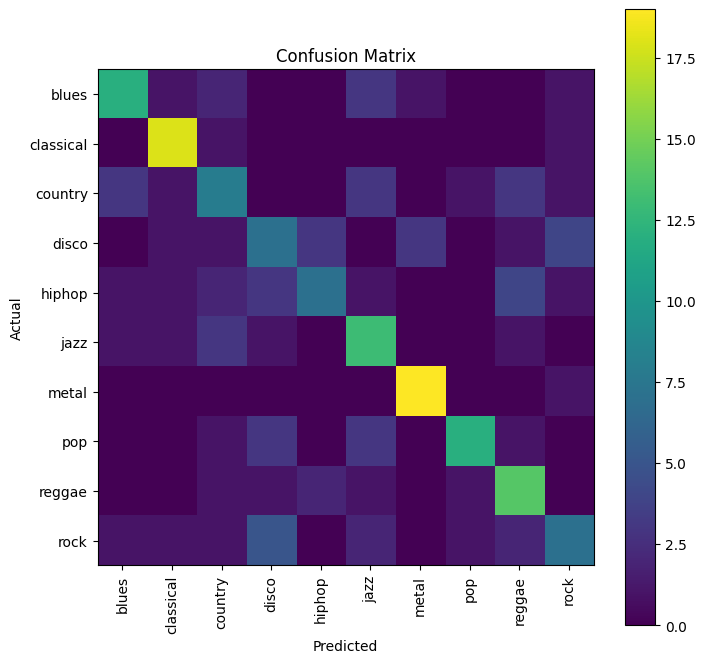

[[12  1  2  0  0  3  1  0  0  1]
 [ 0 18  1  0  0  0  0  0  0  1]
 [ 3  1  8  0  0  3  0  1  3  1]
 [ 0  1  1  7  3  0  3  0  1  4]
 [ 1  1  2  3  7  1  0  0  4  1]
 [ 1  1  3  1  0 13  0  0  1  0]
 [ 0  0  0  0  0  0 19  0  0  1]
 [ 0  0  1  3  0  3  0 12  1  0]
 [ 0  0  1  1  2  1  0  1 14  0]
 [ 1  1  1  5  0  2  0  1  2  7]]


In [81]:
from sklearn.metrics import confusion_matrix
import matplotlib.pyplot as plt
cm = confusion_matrix(y_test, pred)
plt.figure(figsize=(8,8))
plt.imshow(cm)
plt.colorbar()
plt.xticks(
    range(len(encoder.classes_)),
    encoder.classes_,
    rotation=90
)
plt.yticks(
    range(len(encoder.classes_)),
    encoder.classes_
)
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")
plt.show()
print(cm)

In [84]:
feature_names = [
    "MFCC_1","MFCC_2","MFCC_3","MFCC_4","MFCC_5","MFCC_6","MFCC_7","MFCC_8","MFCC_9","MFCC_10","MFCC_11","MFCC_12","MFCC_13","Dominant_Frequency","Low_Energy","Mid_Energy","High_Energy","Spectral_Centroid","Spectral_Bandwidth","ZCR"
]

In [112]:
#fature importance
import pandas as pd
importance = pd.DataFrame({
    "Feature": feature_names,
    "Importance": model.feature_importances_
})
importance = importance.sort_values(
    by="Importance",
    ascending=False
)
print(importance)

               Feature  Importance
14          Low_Energy    0.090880
16         High_Energy    0.063746
3               MFCC_4    0.062648
8               MFCC_9    0.058860
18  Spectral_Bandwidth    0.056752
2               MFCC_3    0.051378
19                 ZCR    0.050720
0               MFCC_1    0.049425
13  Dominant_Frequency    0.049356
5               MFCC_6    0.048876
10             MFCC_11    0.047589
17   Spectral_Centroid    0.046852
15          Mid_Energy    0.043482
11             MFCC_12    0.043233
7               MFCC_8    0.041993
4               MFCC_5    0.041438
12             MFCC_13    0.041153
1               MFCC_2    0.040300
6               MFCC_7    0.038407
9              MFCC_10    0.032914


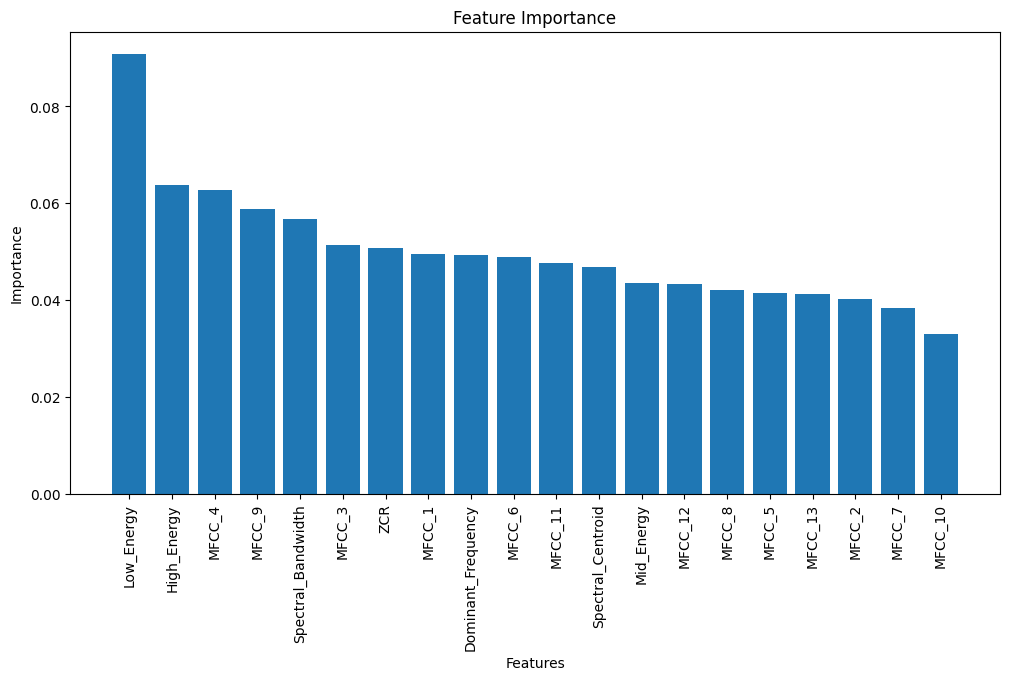

In [86]:
#plotting feature importance
import matplotlib.pyplot as plt

plt.figure(figsize=(12,6))

plt.bar(
    importance["Feature"],
    importance["Importance"]
)

plt.xticks(rotation=90)

plt.title("Feature Importance")
plt.xlabel("Features")
plt.ylabel("Importance")

plt.show()

In [120]:
print("Accuracy using Random Forest:", acc)

Accuracy using Random Forest: 0.6779661016949152


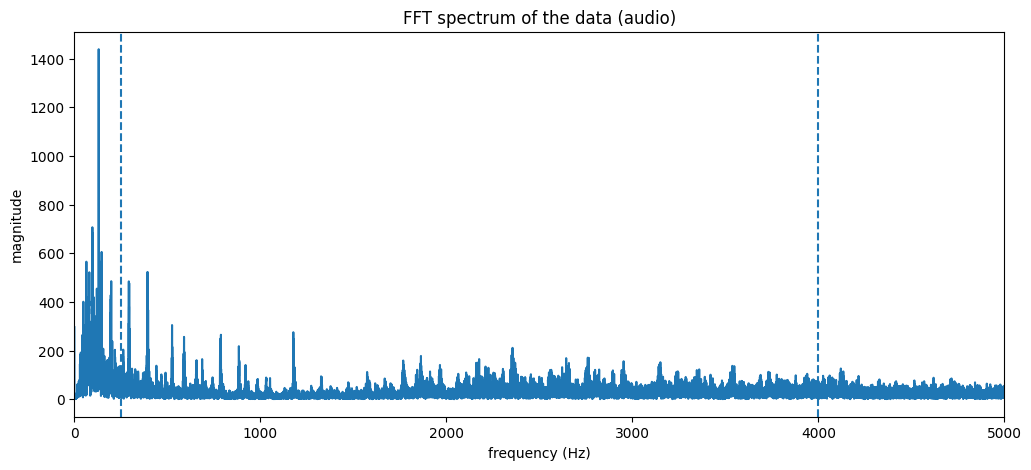

In [118]:
import librosa
import numpy as np
import matplotlib.pyplot as plt

sample = "/content/data/genres_original/metal/metal.00000.wav"
y, sr = librosa.load(sample, sr=22050, duration=5)
fft = np.abs(np.fft.rfft(y))
freqs = np.fft.rfftfreq(len(y), d=1/sr)
plt.figure(figsize=(12,5))
plt.plot(freqs, fft)
plt.axvline(250, linestyle='--')
plt.axvline(4000, linestyle='--')
plt.xlim(0, 5000)
plt.xlabel("frequency (Hz)")
plt.ylabel("magnitude")
plt.title("FFT spectrum of the data (audio)")
plt.show()